In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [50]:
transactions = pd.read_csv("../data/tb_transaction.csv")
customers = pd.read_csv("../data/tb_cust.csv")

In [51]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [52]:
transaction_type = (
    transactions["transaction_type"]
    .value_counts()
)

transaction_type

transaction_type
Shopping Payment    120203
Bank Transfer        79797
Name: count, dtype: int64

In [53]:
transaction_type_pct = (
    transactions["transaction_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

transaction_type_pct

transaction_type
Shopping Payment    60.1
Bank Transfer       39.9
Name: proportion, dtype: float64

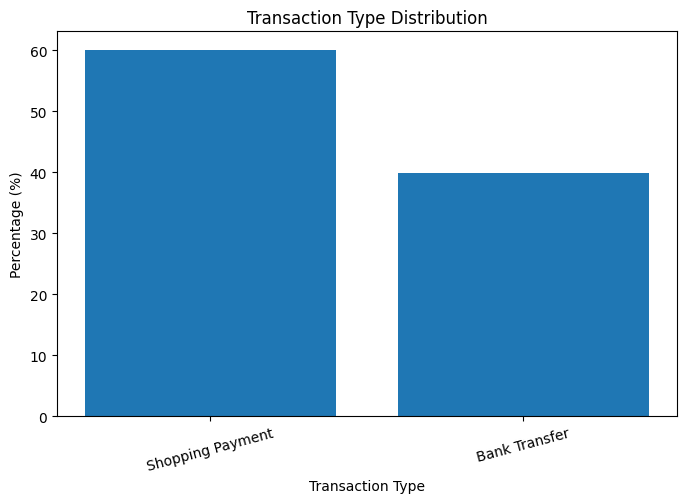

In [54]:
plt.figure(figsize=(8, 5))

plt.bar(
    transaction_type_pct.index,
    transaction_type_pct.values
)

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=15)

plt.show()

In [55]:
amount_stats = transactions["amount"].agg(
    [
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ]
)

amount_stats

count     2.000000e+05
mean      3.075336e+05
median    2.035073e+05
std       3.430042e+05
min       1.000000e+04
max       1.000000e+07
Name: amount, dtype: float64

In [56]:
print(
    f"Mean: Rp {transactions['amount'].mean():,.0f}"
)

print(
    f"Median: Rp {transactions['amount'].median():,.0f}"
)

Mean: Rp 307,534
Median: Rp 203,507


In [57]:
amount_by_type = (
    transactions
    .groupby("transaction_type")["amount"]
    .agg(
        ["count", "mean", "median", "sum"]
    )
    .reset_index()
)

amount_by_type

,transaction_type,count,mean,median,sum
0,Bank Transfer,79797,481992.384818,350526.59,3.846155e+10
1,Shopping Payment,120203,191718.728036,150217.86,2.304517e+10


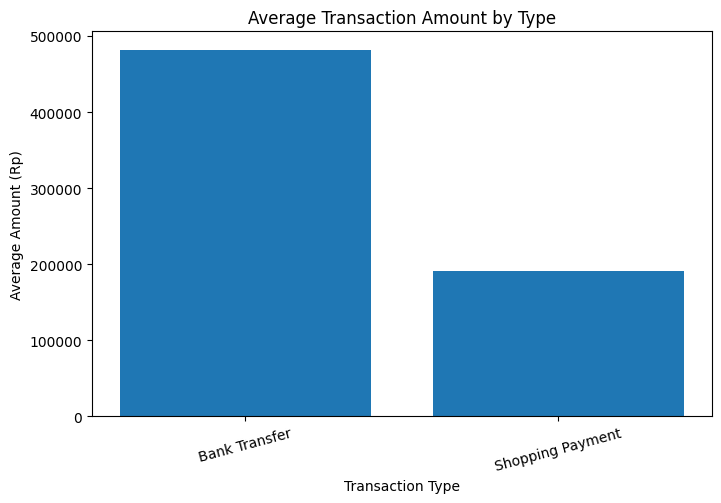

In [58]:
plt.figure(figsize=(8, 5))

plt.bar(
    amount_by_type["transaction_type"],
    amount_by_type["mean"]
)

plt.title("Average Transaction Amount by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Average Amount (Rp)")

plt.xticks(rotation=15)

plt.show()

In [59]:
transactions["date"] = (
    transactions["transaction_date"].dt.date
)

In [60]:
daily_transactions = (
    transactions
    .groupby("date")
    .size()
)

daily_transactions.describe()

count    546.000000
mean     366.300366
std       23.941394
min       21.000000
25%      355.000000
50%      367.000000
75%      380.000000
max      424.000000
dtype: float64

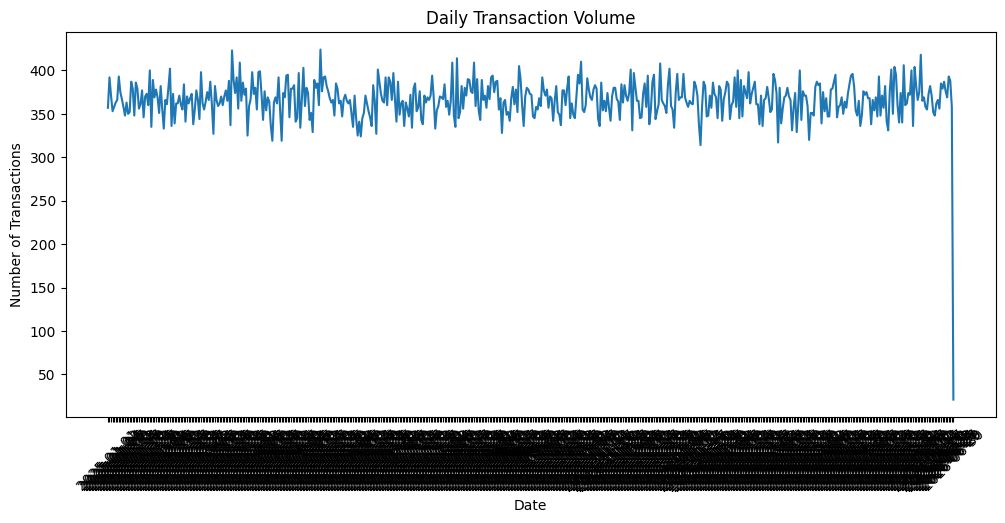

In [61]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_transactions.index.astype(str),
    daily_transactions.values
)

plt.title("Daily Transaction Volume")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

In [62]:
daily_transactions.nlargest(10)

date
2025-05-18    424
2025-03-22    423
2026-06-09    418
2025-08-14    414
2025-11-02    410
2025-03-27    409
2025-08-11    409
2025-08-25    409
2025-12-23    408
2026-05-29    406
dtype: int64

In [63]:
transactions["month"] = (
    transactions["transaction_date"]
    .dt.to_period("M")
)

monthly_type = (
    transactions
    .groupby(
        ["month", "transaction_type"]
    )
    .size()
    .unstack(fill_value=0)
)

monthly_type

transaction_type,Bank Transfer,Shopping Payment
month,,
2025-01,4484,6897
2025-02,4076,6095
2025-03,4561,6959
2025-04,4358,6625
2025-05,4580,6918
2025-06,4191,6559
2025-07,4488,6800
2025-08,4584,6887
2025-09,4466,6602


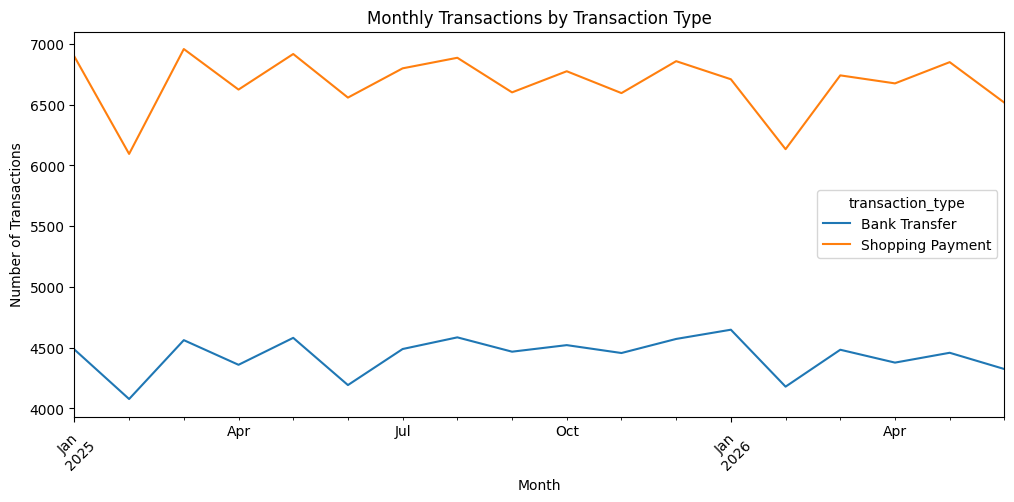

In [64]:
monthly_type.plot(
    kind="line",
    figsize=(12, 5)
)

plt.title("Monthly Transactions by Transaction Type")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

In [65]:
transactions["day_of_week"] = (
    transactions["transaction_date"]
    .dt.day_name()
)

In [66]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_transactions = (
    transactions["day_of_week"]
    .value_counts()
    .reindex(weekday_order)
)

weekday_transactions

day_of_week
Monday       28674
Tuesday      28240
Wednesday    28619
Thursday     28519
Friday       28478
Saturday     28719
Sunday       28751
Name: count, dtype: int64

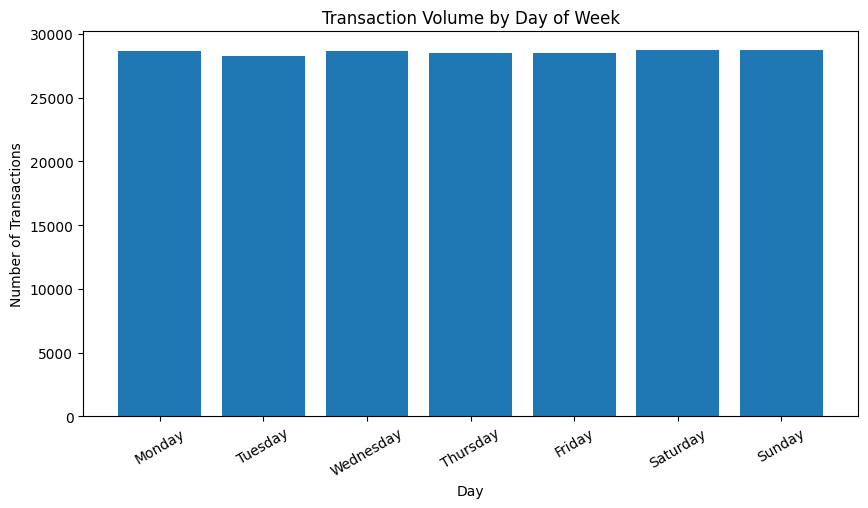

In [67]:
plt.figure(figsize=(10, 5))

plt.bar(
    weekday_transactions.index,
    weekday_transactions.values
)

plt.title("Transaction Volume by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=30)

plt.show()

In [68]:
transaction_customer = transactions.merge(
    customers[
        [
            "customer_id",
            "customer_segment",
            "city"
        ]
    ],
    on="customer_id",
    how="left"
)

In [69]:
segment_transactions = (
    transaction_customer
    .groupby("customer_segment")
    .agg(
        transactions=("transaction_id", "count"),
        transaction_value=("amount", "sum"),
        average_transaction=("amount", "mean")
    )
    .reset_index()
)

segment_transactions

,customer_segment,transactions,transaction_value,average_transaction
0,College Student,69646,2.142624e+10,307644.967694
1,High School Student,51832,1.585327e+10,305858.734741
2,Office Worker,78522,2.422720e+10,308540.297475


In [70]:
segment_type = (
    transaction_customer
    .groupby(
        [
            "customer_segment",
            "transaction_type"
        ]
    )
    .agg(
        transactions=("transaction_id", "count"),
        transaction_value=("amount", "sum"),
        average_transaction=("amount", "mean")
    )
    .reset_index()
)

segment_type

,customer_segment,transaction_type,transactions,transaction_value,average_transaction
0,College Student,Bank Transfer,27867,1.343858e+10,482239.914740
1,College Student,Shopping Payment,41779,7.987662e+09,191188.437156
2,High School Student,Bank Transfer,20688,9.877526e+09,477451.974536
3,High School Student,Shopping Payment,31144,5.975743e+09,191874.630423
4,Office Worker,Bank Transfer,31242,1.514544e+10,484778.188913
5,Office Worker,Shopping Payment,47280,9.081761e+09,192084.624794
